In [1]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from faker import Faker
import random

A hospital wants to analyze patient stay patterns and treatment costs.

Create a dataset of at least 400 patients containing:
patient_id, age, gender, diagnosis, hospital_days, treatment_cost


In [2]:
fake=Faker()
data=[]
gender=["Male","Female"]
diagnosis=["Hypertension","Diabetes","Asthma","Heart Disease","Fracture","Flu","Arthritis", "Migraine"]
for i in range(400):
    data.append({
        "patient_id":fake.uuid4(),
        "age":fake.random_int(min=1,max=90),
        "gender":random.choice(gender),
        "diagnosis":random.choice(diagnosis),
        "hospital_days":fake.random_int(min=1,max=30),
        "treatment_cost":fake.random_int(min=1500,max=10000)
    })
df=pd.DataFrame(data)
df.to_csv("Hospital_data.csv",index=False)
print(df.head(10))

                             patient_id  age  gender     diagnosis  \
0  6ec32a0d-f935-494c-99f3-255c53c42298   43  Female     Arthritis   
1  324e660c-7b75-4f10-9fbf-cc006eb93d62   48    Male     Arthritis   
2  4364746a-0de8-43de-8bbf-7d6e2a515327   79    Male           Flu   
3  da1c0cea-5192-4ae3-9695-1b82f937c611    5  Female  Hypertension   
4  7f1ab6d2-bb39-4f8d-b258-729463b25602   64    Male      Migraine   
5  036b50f9-8f59-4485-b171-9f13c262d6bf   43  Female      Fracture   
6  55f9be12-35be-4bbe-9eba-0d2818e2f98e   63    Male           Flu   
7  0ba75fec-83c8-4e3c-8d16-6809498f3235    3    Male           Flu   
8  768fbe11-7d3d-4911-8c82-1a73531a85d3   85    Male        Asthma   
9  1844bef0-dfb6-4b19-b02e-1d607015d795    1  Female      Diabetes   

   hospital_days  treatment_cost  
0              7            4017  
1              9            5132  
2             25            5478  
3             22            3273  
4              8            9813  
5             24   

Using Pandas:
Compute average hospital stay per diagnosis

In [3]:
avg_stay=df.groupby("diagnosis")["hospital_days"].mean().reset_index()
avg_stay.rename(columns={"hospital_days":"avg_stay"},inplace=True)
avg_stay


,diagnosis,avg_stay
0,Arthritis,15.640000
1,Asthma,13.437500
2,Diabetes,15.072727
3,Flu,12.133333
4,Fracture,15.586957
5,Heart Disease,16.641026
6,Hypertension,16.036364
7,Migraine,13.680851


Segment patients into age groups.

In [4]:
age_grp=[1,18,40,60,80,90]
label=["1-18","18-40","40-60","60-80","80-90"]
df["age_grp"]=pd.cut(df["age"], bins=age_grp,labels=label,right=True)
print(df.head(10))

                             patient_id  age  gender     diagnosis  \
0  6ec32a0d-f935-494c-99f3-255c53c42298   43  Female     Arthritis   
1  324e660c-7b75-4f10-9fbf-cc006eb93d62   48    Male     Arthritis   
2  4364746a-0de8-43de-8bbf-7d6e2a515327   79    Male           Flu   
3  da1c0cea-5192-4ae3-9695-1b82f937c611    5  Female  Hypertension   
4  7f1ab6d2-bb39-4f8d-b258-729463b25602   64    Male      Migraine   
5  036b50f9-8f59-4485-b171-9f13c262d6bf   43  Female      Fracture   
6  55f9be12-35be-4bbe-9eba-0d2818e2f98e   63    Male           Flu   
7  0ba75fec-83c8-4e3c-8d16-6809498f3235    3    Male           Flu   
8  768fbe11-7d3d-4911-8c82-1a73531a85d3   85    Male        Asthma   
9  1844bef0-dfb6-4b19-b02e-1d607015d795    1  Female      Diabetes   

   hospital_days  treatment_cost age_grp  
0              7            4017   40-60  
1              9            5132   40-60  
2             25            5478   60-80  
3             22            3273    1-18  
4             

Using NumPy:
Identify treatment cost anomalies.

In [5]:
arr=df["treatment_cost"].to_numpy()
mean=np.mean(arr)
std=np.std(arr)
k=2
z_score=(arr-mean)/std
upper_thersold=mean+k*std
lower_thersold=mean-k*std
# print(lower_thersold,upper_thersold,arr.min(),arr.max())
# outlier=(df[np.abs(z_score)>k])
outlier=df[(df["treatment_cost"]<lower_thersold) | (df["treatment_cost"]>upper_thersold)]
print(outlier)

Empty DataFrame
Columns: [patient_id, age, gender, diagnosis, hospital_days, treatment_cost, age_grp]
Index: []


Apply suitable transformations to normalize cost data.

In [6]:
# transform treatmenmt cost in logarithmic data
df["treatment_cost_log"]=np.log(df["treatment_cost"])
print(df[["treatment_cost","treatment_cost_log"]].head(10))

   treatment_cost  treatment_cost_log
0            4017            8.298291
1            5132            8.543251
2            5478            8.608495
3            3273            8.093462
4            9813            9.191463
5            4199            8.342602
6            6390            8.762490
7            5437            8.600983
8            6460            8.773385
9            5581            8.627123


In [7]:
sqrt_cost_log=np.sqrt(df["treatment_cost"])
print(sqrt_cost_log)

0      63.379808
1      71.637979
2      74.013512
3      57.210139
4      99.060588
         ...    
395    97.836598
396    73.130021
397    93.246984
398    59.924953
399    84.604964
Name: treatment_cost, Length: 400, dtype: float64


Using a visualization library:
Compare hospital stay across diagnoses.

C:\Users\shrey\AppData\Local\Temp\ipykernel_1204\2415687459.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(stay,labels=diag)


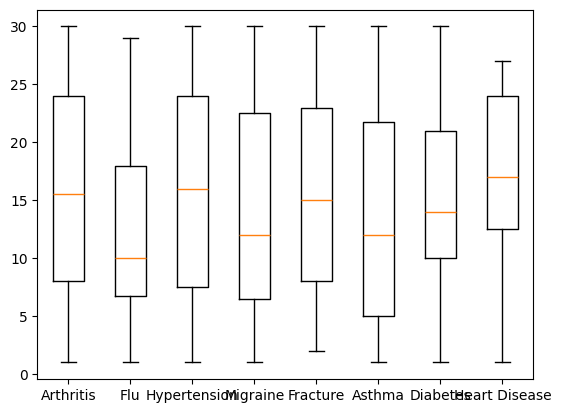

In [8]:
diag=df["diagnosis"].unique()
stay=[df[df["diagnosis"]==s]["hospital_days"]for s in diag] 
plt.boxplot(stay,labels=diag)

plt.show()

Visualize cost patterns across age groups.

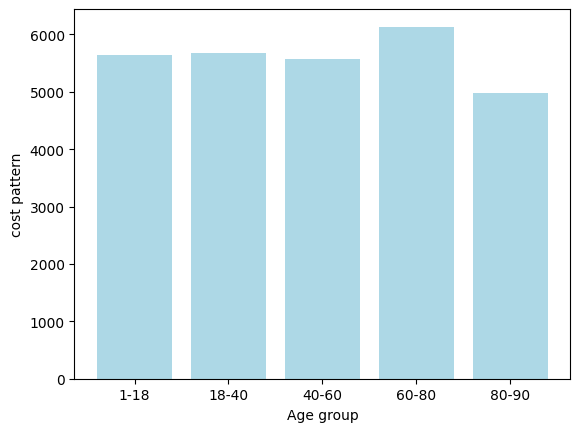

In [9]:
avg_cost = df.groupby("age_grp")["treatment_cost"].mean()
plt.bar(avg_cost.index, avg_cost.values, color="lightblue")
plt.xlabel("Age group")
plt.ylabel("cost pattern")
plt.show()

C:\Users\shrey\AppData\Local\Temp\ipykernel_1204\3081789709.py:4: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(cost_groups, labels=age_groups)


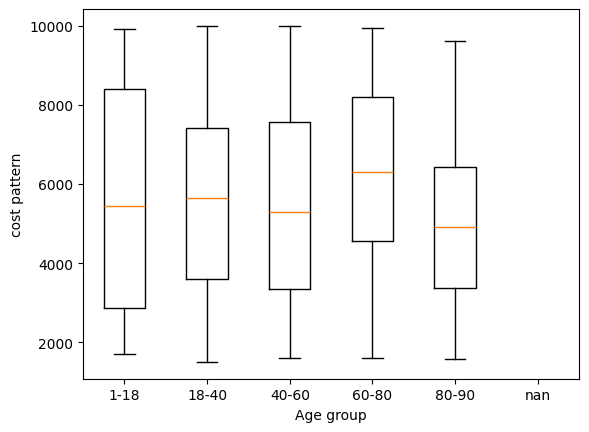

In [10]:
# Group treatment costs by age group
age_groups = df["age_grp"].sort_values().unique()
cost_groups = [df[df["age_grp"] == g]["treatment_cost"] for g in age_groups]
plt.boxplot(cost_groups, labels=age_groups)
plt.xlabel("Age group")
plt.ylabel("cost pattern")
plt.show()